## Import Required Libraries

This section imports the essential Python libraries used for data manipulation, numerical computations, and data visualization throughout the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## Define Dataset Path

This section defines the base project directory and constructs a relative path to the dataset file using `pathlib` for better portability and cleaner project structure.

In [2]:
from pathlib import Path

BASE_DIR = Path().resolve().parent
data_path=BASE_DIR / 'data' / 'raw' / 'heart.csv'

In [3]:
print(BASE_DIR)
print(data_path)

C:\AI_PROJECTS\patient-risk-prediction
C:\AI_PROJECTS\patient-risk-prediction\data\raw\heart.csv


## Load the Dataset

The dataset is loaded into a Pandas DataFrame to begin the data exploration and preprocessing مراحل.

In [4]:
df = pd.read_csv(data_path)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.shape

(1025, 14)

In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [9]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Check for Duplicate Records

This step checks for fully duplicated rows in the dataset to identify potential data quality issues that may affect model performance and evaluation reliability.

In [11]:
df.duplicated().sum()

np.int64(723)

In [12]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(by=list(df.columns)).head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
60,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
64,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
118,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
668,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
12,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
779,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
143,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1
201,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1
572,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1


## Remove Duplicate Records

Duplicate rows are removed from the dataset to improve data quality, reduce redundancy, and help prevent data leakage during model training and evaluation.


In [13]:
df=df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(302, 14)

## Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets to evaluate the model on unseen data. Stratified sampling is used to preserve the original target class distribution and reduce sampling bias.

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_set = X_train.copy()
train_set["target"] = y_train

test_set = X_test.copy()
test_set["target"] = y_test


In [17]:
print('train set shape : ',train_set.shape)

train set shape :  (241, 14)


In [18]:
print('test set shape : ',test_set.shape)

test set shape :  (61, 14)


## Verify Target Class Distribution

This step checks the distribution of the target classes in both the training and testing sets to ensure that stratified sampling preserved the original class balance.

In [19]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

target
1    0.543568
0    0.456432
Name: proportion, dtype: float64
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


In [20]:
train_set['sex'].value_counts(normalize=True)

sex
1    0.676349
0    0.323651
Name: proportion, dtype: float64

In [21]:
test_set['sex'].value_counts(normalize=True)

sex
1    0.704918
0    0.295082
Name: proportion, dtype: float64

## Compare Age Distribution Between Training and Testing Sets

Kernel Density Estimation (KDE) plots are used to compare the age distribution between the training and testing datasets and verify that both sets follow a similar distribution after splitting.

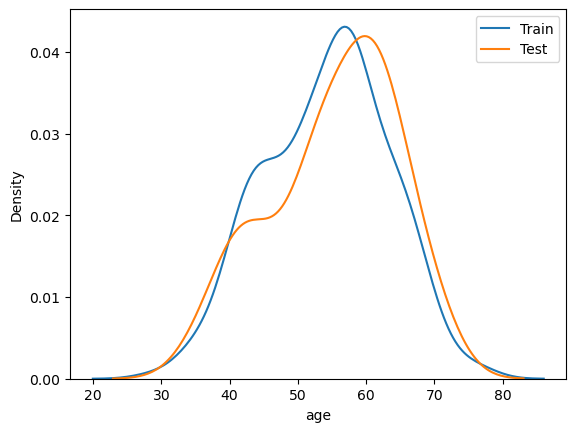

In [22]:
sns.kdeplot(train_set['age'],label='Train')
sns.kdeplot(test_set['age'],label='Test')

plt.legend()
plt.show()


## Discover and vizualize the data to gain insights

In [23]:
train_set.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
199,50,1,0,144,200,0,0,126,1,0.9,1,0,3,0
479,58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
460,69,1,2,140,254,0,0,146,0,2.0,1,3,3,0
169,45,0,1,112,160,0,1,138,0,0.0,1,0,2,1


In [24]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241 entries, 158 to 549
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       241 non-null    int64  
 1   sex       241 non-null    int64  
 2   cp        241 non-null    int64  
 3   trestbps  241 non-null    int64  
 4   chol      241 non-null    int64  
 5   fbs       241 non-null    int64  
 6   restecg   241 non-null    int64  
 7   thalach   241 non-null    int64  
 8   exang     241 non-null    int64  
 9   oldpeak   241 non-null    float64
 10  slope     241 non-null    int64  
 11  ca        241 non-null    int64  
 12  thal      241 non-null    int64  
 13  target    241 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 28.2 KB


In [25]:
train_set.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,54.195021,0.676349,0.983402,131.315353,247.630705,0.136929,0.535270,150.825726,0.298755,0.995436,1.423237,0.759336,2.336100,0.543568
std,9.024004,0.468842,1.032662,16.802286,53.889630,0.344488,0.532096,22.519499,0.458665,1.148994,0.608379,1.052856,0.618385,0.499135
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,138.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,154.000000,0.000000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,277.000000,0.000000,1.000000,167.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,192.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Age Feature Analysis

The statistical summary of the `age` feature shows that the average patient age is approximately 54 years old, with ages ranging from 29 to 77 years.

This suggests that the dataset mainly represents adult and middle-aged to older patients, which is medically reasonable for cardiovascular disease studies since heart disease risk generally increases with age.

In addition, the age range does not appear to contain unrealistic or medically impossible values, indicating that the feature is generally consistent and reliable for further analysis.

### Resting Blood Pressure Analysis

The `trestbps` feature has an average resting blood pressure of approximately 131 mmHg, which is slightly above the normal range and medically plausible in heart disease patients.

The maximum recorded value reaches 192 mmHg, which is relatively high and may indicate hypertensive patients. However, the values still appear medically possible and do not immediately suggest invalid measurements.

Further visualization will help determine whether extreme values or skewed distributions are present.

### Cholesterol Feature Analysis

The `chol` feature shows an average cholesterol level of approximately 247 mg/dl.

However, the maximum value reaches 564 mg/dl, which is unusually high and may represent either a rare medical condition or a potential outlier.

This observation requires additional visual investigation during the exploratory data analysis phase to better understand the distribution and detect possible anomalies.

### Maximum Heart Rate Analysis

The `thalach` feature represents the maximum heart rate achieved by patients during exercise.

The recorded values range from 71 to 202 bpm, which generally falls within medically possible limits.

However, the upper values appear relatively high and may require additional visualization to determine whether they represent natural physiological variation or potential outliers.

### Oldpeak Feature Analysis

The `oldpeak` feature represents ST depression induced by exercise relative to rest.

The statistical summary indicates a maximum value of 6.2, which appears relatively high compared to the average value.

This may suggest the presence of skewed data or potential outliers, requiring deeper visual analysis to better understand the distribution of the feature.

### General Observations

The initial statistical exploration indicates that the dataset is generally clean and does not contain missing values.

Most numerical features appear medically reasonable, although some variables contain extreme values that may require further investigation through visualization techniques such as histograms, KDE plots, and boxplots.

The next step will focus on studying feature distributions, identifying hidden patterns, and detecting potential outliers within the training dataset.

###############################################################################################

## Numerical Features Distribution Analysis

In this section, numerical features will be analyzed to understand their distributions, spread, skewness, and potential outliers.

The analysis will be performed only on the training set to avoid data leakage.

### Age Distribution

The `age` feature will be analyzed to understand the age range of patients, the general distribution pattern, and whether any unusual values are present.

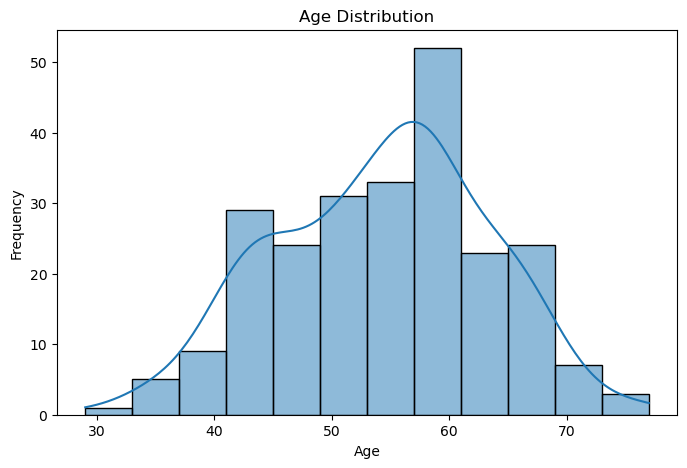

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(train_set["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Age Distribution Analysis

The age distribution appears approximately bell-shaped with a slight right skewness.

Most patients fall within the age range of 45 to 65 years, which is medically reasonable for cardiovascular disease datasets since heart disease risk generally increases with age.

The distribution does not appear to contain unrealistic values or severe irregularities, and no obvious abnormal patterns are visible from the histogram.

Overall, the `age` feature appears relatively stable and suitable for further machine learning analysis.

##################################################

### Age Boxplot Analysis

A boxplot is used to investigate the spread of the `age` feature and detect potential outliers or unusual age values within the training dataset.

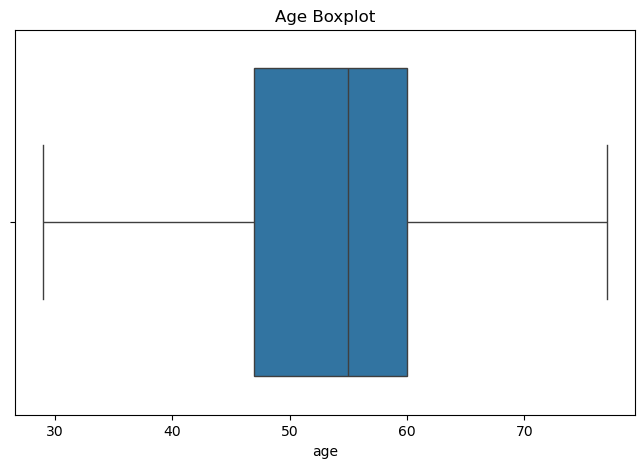

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_set["age"])

plt.title("Age Boxplot")

plt.show()

### Age Boxplot Analysis

The boxplot of the `age` feature shows that the median patient age is approximately in the mid-50s, while the majority of patient ages are concentrated roughly between 47 and 60 years.

No obvious outliers are visible in the distribution, indicating that the age values remain within a medically reasonable range.

In addition, the right whisker appears slightly longer than the left whisker, suggesting a mild right skewness in the age distribution. However, the skewness does not appear severe.

Overall, the `age` feature demonstrates a stable distribution without significant abnormalities or extreme values.

##################################################

### Cholesterol Distribution

The `chol` feature will be analyzed to investigate the distribution of cholesterol levels, detect potential skewness, and identify possible outliers or unusual medical values.

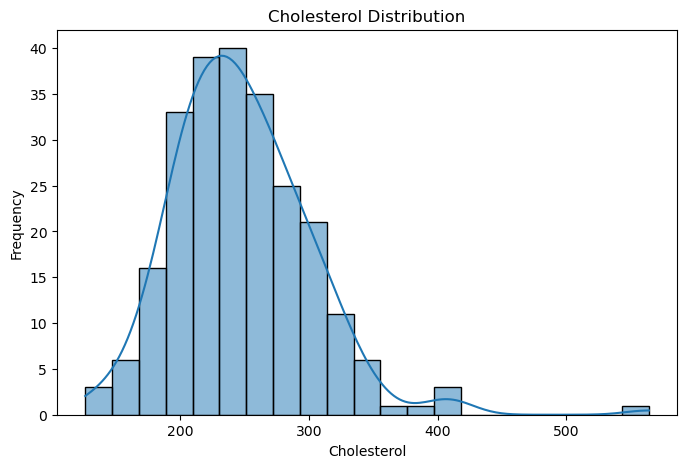

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(train_set["chol"], kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

### Cholesterol Distribution Analysis

The cholesterol distribution appears moderately right-skewed, with most patient values concentrated roughly between 180 and 320 mg/dl.

While the central portion of the distribution resembles a near-normal shape, the long right tail indicates the presence of several unusually high cholesterol values.

Some extreme values above 400 mg/dl, including values exceeding 500 mg/dl, may represent potential outliers or severe medical conditions. However, no conclusions should be made at this stage without further investigation.

Additional visualization using boxplots will help better evaluate the presence and severity of possible outliers.

##################################################

### Cholesterol Boxplot Analysis

A boxplot will be used to further investigate the spread of cholesterol values and identify potential outliers within the dataset.

This visualization helps provide a clearer view of extreme values, variability, and possible abnormalities that may not be fully visible in the histogram alone.

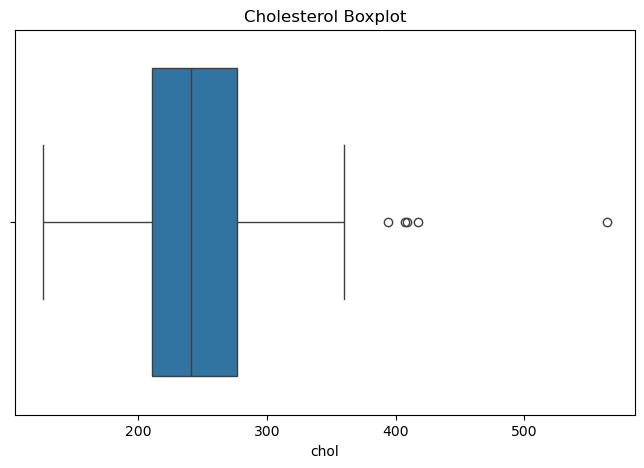

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_set["chol"])

plt.title("Cholesterol Boxplot")

plt.show()

### Cholesterol Boxplot Analysis

The boxplot confirms the presence of several high cholesterol outliers, particularly for values above 400 mg/dl.

One extreme value appears significantly distant from the main distribution, exceeding approximately 550 mg/dl.

These values are considered statistical outliers because they lie far beyond the typical cholesterol range observed in most patients.

However, since this is a medical dataset, such extreme values may still represent real high-risk clinical cases rather than simple measurement errors.

At this stage, the outliers will not be removed immediately. Further preprocessing and model evaluation will help determine whether special handling is required.

##################################################

### Oldpeak Distribution

The `oldpeak` feature will be analyzed to study its distribution, detect potential skewness, and identify possible outliers related to ST depression measurements.

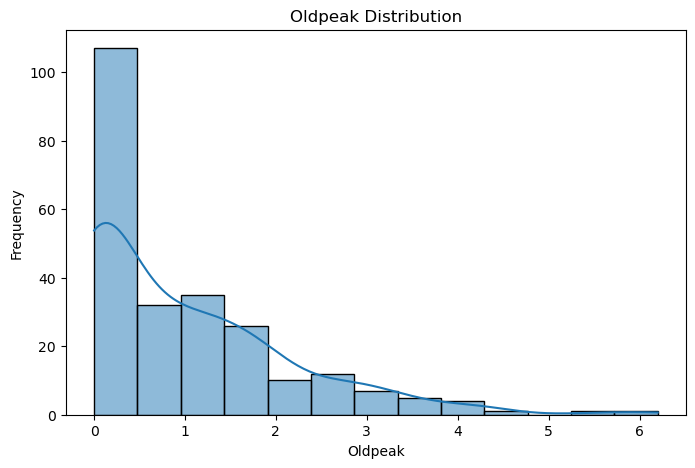

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(train_set["oldpeak"], kde=True)

plt.title("Oldpeak Distribution")
plt.xlabel("Oldpeak")
plt.ylabel("Frequency")

plt.show()

### Oldpeak Distribution Analysis

The distribution of the `oldpeak` feature appears highly right-skewed and noticeably non-symmetric.

Most patient values are concentrated between 0 and 2, while a smaller number of observations extend toward higher values above 3.

The long right tail suggests the presence of relatively rare but significantly elevated ST depression values.

This asymmetry indicates that the feature is not normally distributed and may contain extreme clinical cases or potential outliers.

From a medical perspective, elevated oldpeak values may be associated with more severe cardiac abnormalities, making this feature potentially important for risk prediction.

##################################################

### Oldpeak Boxplot Analysis

A boxplot will be used to further investigate the spread of the `oldpeak` feature and identify potential outliers or unusually high ST depression values.

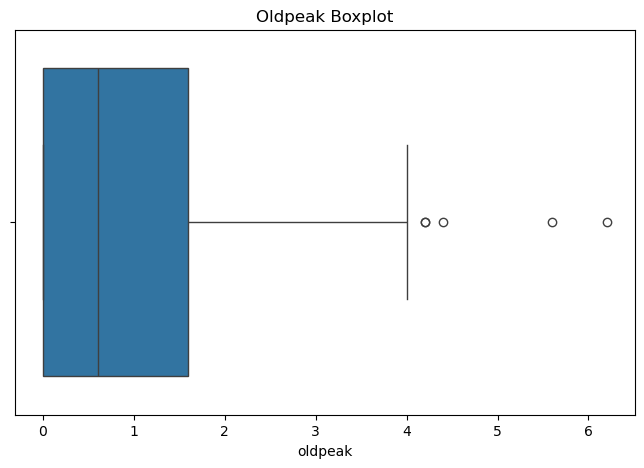

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_set["oldpeak"])

plt.title("Oldpeak Boxplot")

plt.show()

### Oldpeak Boxplot Analysis

The boxplot confirms that the `oldpeak` feature is highly right-skewed, with the majority of values concentrated near the lower end of the scale.

The median value appears to be below 1, indicating that most patients have relatively low ST depression values.

Several distinct outliers are visible above approximately 4, including a few extreme values near 6.

These observations suggest that while most patients fall within a lower oldpeak range, a smaller number of patients exhibit significantly elevated values.

From a clinical perspective, these extreme observations may represent patients with more severe cardiac abnormalities rather than simple measurement errors.

At this stage, the outliers will be retained for further investigation during preprocessing and model evaluation.

##################################################

### Resting Blood Pressure Distribution

The `trestbps` feature will be analyzed to investigate the distribution of resting blood pressure values, identify possible skewness, and detect potential outliers within the dataset.

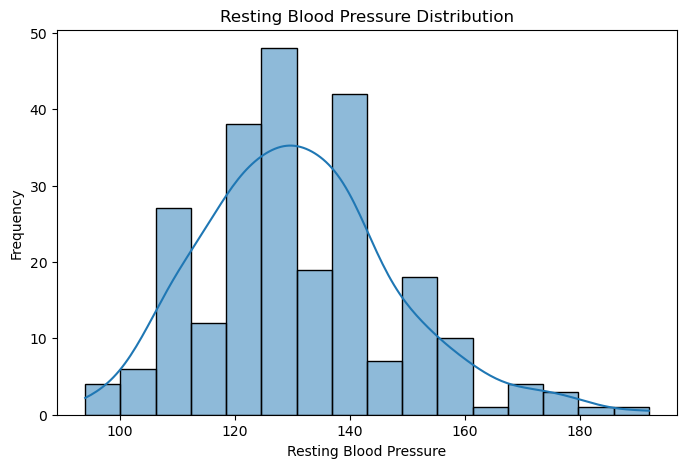

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(train_set["trestbps"], kde=True)

plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Frequency")

plt.show()

### Resting Blood Pressure Distribution Analysis

The distribution of the `trestbps` feature appears approximately normal with a slight right skewness.

Most resting blood pressure values are concentrated roughly between 115 and 145 mmHg, which falls within a medically plausible range for patients undergoing cardiovascular evaluation.

Although a few higher blood pressure values extend beyond 160 mmHg, they do not appear excessively abnormal from the histogram alone.

The distribution also shows some natural variability across patients, suggesting that resting blood pressure alone may not be sufficient to clearly distinguish patient conditions without considering additional clinical features.

Overall, the feature appears relatively stable and medically consistent for further analysis.

##################################################

### Resting Blood Pressure Boxplot Analysis

A boxplot will be used to further investigate the spread of resting blood pressure values and identify potential outliers or unusually high measurements within the dataset.

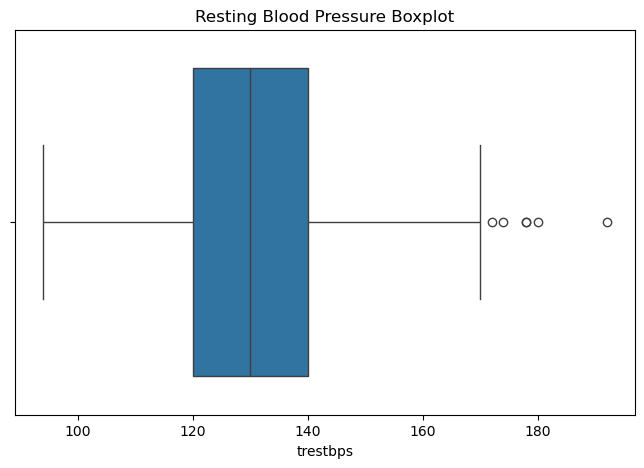

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_set["trestbps"])

plt.title("Resting Blood Pressure Boxplot")

plt.show()

### Resting Blood Pressure Boxplot Analysis

The boxplot shows that most resting blood pressure values are concentrated roughly between 120 and 140 mmHg, with a median around 130 mmHg.

A slight right skewness is visible, as the upper whisker extends further toward higher values.

Several outliers appear above approximately 170 mmHg, including one value approaching 190 mmHg.

Although these measurements are statistically considered outliers, they may still represent medically plausible cases of hypertension or severe cardiovascular conditions rather than simple data errors.

Overall, the feature demonstrates relatively stable behavior with a limited number of elevated observations that may require additional consideration during preprocessing.

##################################################

### Maximum Heart Rate Distribution

The `thalach` feature will be analyzed to investigate the distribution of maximum heart rate values achieved by patients during exercise, identify potential skewness, and detect possible outliers.

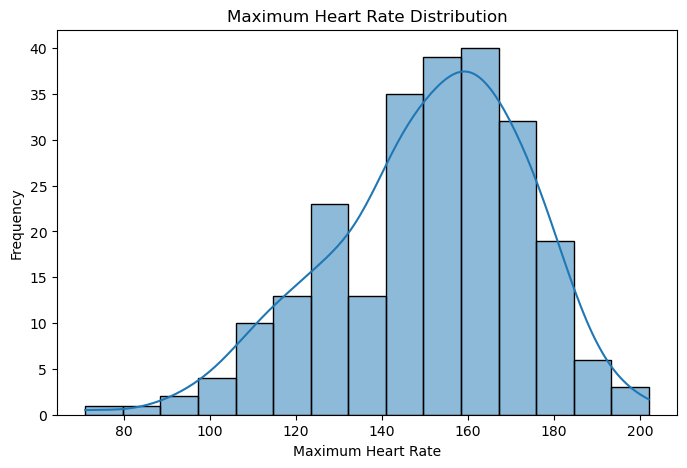

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(train_set["thalach"], kde=True)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Frequency")

plt.show()

### Maximum Heart Rate Distribution Analysis

The distribution of the `thalach` feature appears relatively close to a normal distribution with only mild asymmetry.

Most patient values are concentrated roughly between 140 and 175 bpm, indicating that the majority of patients achieved moderate to high maximum heart rates during exercise testing.

The distribution does not exhibit strong skewness or unusually long tails compared to some of the previously analyzed features.

A few lower heart rate values are present, but they still appear medically plausible and do not immediately suggest abnormal measurements.

Overall, the `thalach` feature appears relatively stable and well-distributed for further machine learning analysis.

##################################################

### Maximum Heart Rate Boxplot Analysis

A boxplot will be used to further investigate the spread of maximum heart rate values and identify potential outliers or unusual observations within the dataset.

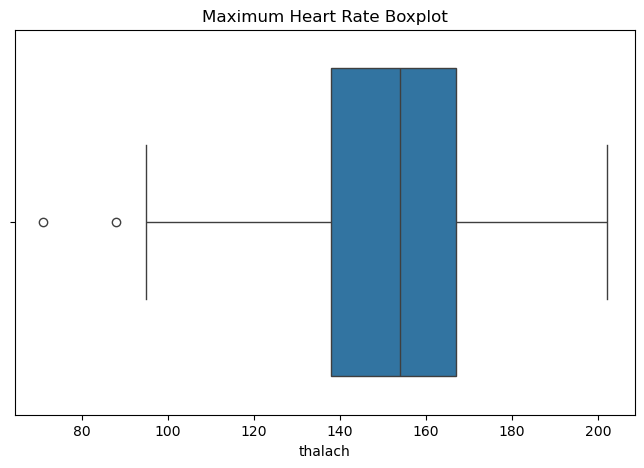

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_set["thalach"])

plt.title("Maximum Heart Rate Boxplot")

plt.show()

### Maximum Heart Rate Boxplot Analysis

The boxplot shows that most maximum heart rate values are concentrated roughly between 140 and 170 bpm, with a median around 155 bpm.

The distribution appears relatively symmetric with only mild asymmetry toward lower values.

A small number of low-value outliers are visible below approximately 90 bpm, indicating that a few patients achieved unusually low maximum heart rates compared to the majority of the dataset.

From a clinical perspective, these observations may represent patients with reduced exercise tolerance, advanced cardiovascular conditions, or age-related physiological limitations rather than simple measurement errors.

Overall, the `thalach` feature appears relatively stable with limited outlier influence.

###############################################################################################

## Numerical Features vs Target Analysis

In this section, numerical features will be analyzed in relation to the target variable to investigate whether certain clinical measurements differ between patients with and without heart disease.

The objective is to identify potentially informative patterns and medically relevant relationships that may help improve machine learning model performance.

### Age vs Target

The relationship between patient age and heart disease presence will be analyzed to investigate whether age distributions differ between patients with and without cardiovascular disease.

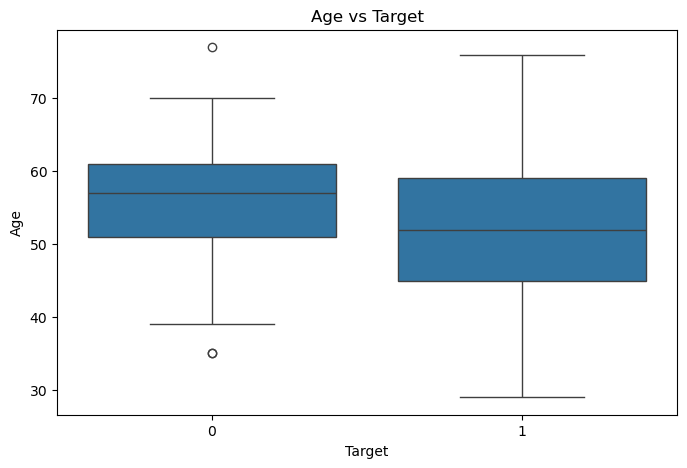

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="age", data=train_set)

plt.title("Age vs Target")
plt.xlabel("Target")
plt.ylabel("Age")

plt.show()

### Age vs Target Analysis

The boxplot shows that both patient groups exhibit overlapping age distributions, indicating that age alone may not be sufficient to clearly distinguish between patients with and without heart disease.

Although slight differences in median age are visible between the two groups, the separation is not substantial.

The heart disease group also appears to exhibit a somewhat wider spread of age values, suggesting greater variability among affected patients.

Several younger and older observations are present in both groups, but they remain medically plausible and do not appear abnormal.

Overall, the `age` feature may still contribute useful information to the machine learning model, especially when combined with other clinical variables, but it does not appear to act as a strong standalone predictor.

##################################################

### Oldpeak vs Target

The relationship between `oldpeak` values and heart disease presence will be analyzed to investigate whether ST depression measurements differ between patients with and without cardiovascular disease.

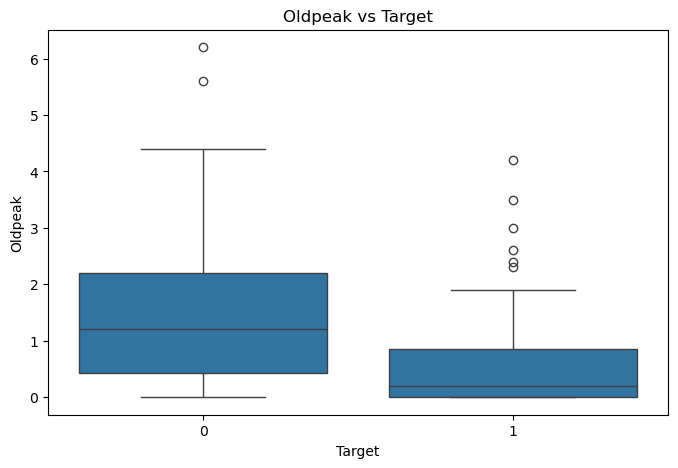

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="oldpeak", data=train_set)

plt.title("Oldpeak vs Target")
plt.xlabel("Target")
plt.ylabel("Oldpeak")

plt.show()

### Oldpeak vs Target Analysis

The boxplot reveals a noticeably clearer separation between the two target groups compared to the previously analyzed `age` feature.

One group exhibits substantially higher oldpeak values and a wider spread, while the other group is concentrated near lower values.

The distributions still overlap to some extent; however, the overlap appears considerably smaller than that observed in the age analysis.

These observations suggest that the `oldpeak` feature may carry stronger discriminative information regarding heart disease status compared to age alone.

Several elevated outliers are also visible, indicating the presence of patients with unusually high ST depression values.

Overall, `oldpeak` appears to be a potentially informative feature for machine learning prediction, although it is still unlikely to fully determine disease presence on its own.

##################################################

### Maximum Heart Rate vs Target

The relationship between maximum heart rate (`thalach`) and heart disease presence will be analyzed to investigate whether exercise heart rate patterns differ between the two patient groups.

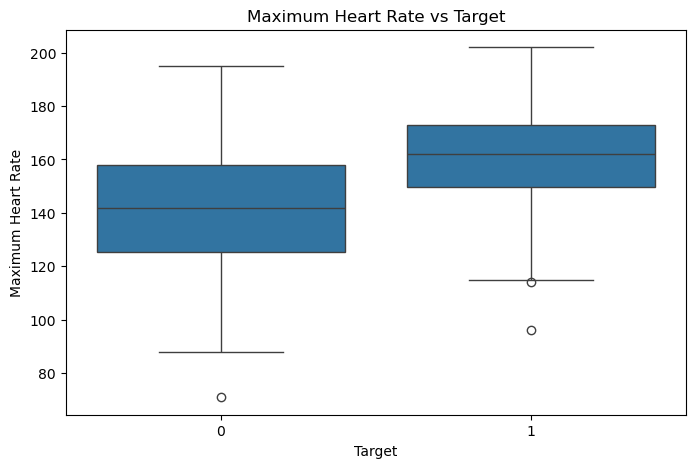

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="thalach", data=train_set)

plt.title("Maximum Heart Rate vs Target")
plt.xlabel("Target")
plt.ylabel("Maximum Heart Rate")

plt.show()

### Maximum Heart Rate vs Target Analysis

The boxplot shows noticeable differences in maximum heart rate distributions between the two target groups.

One group generally exhibits higher maximum heart rate values, while the other group tends to have lower values overall.

Compared to the previously analyzed `age` feature, the overlap between the two groups appears smaller, suggesting that `thalach` may provide stronger discriminative information.

However, the separation is still not complete, indicating that maximum heart rate alone is unlikely to fully determine heart disease status.

A few low-value outliers are also present, which may represent patients with reduced exercise tolerance or more severe cardiovascular limitations rather than measurement errors.

Overall, the `thalach` feature appears moderately informative for heart disease prediction and potentially more useful than age, although likely less discriminative than `oldpeak`.

##################################################

### Cholesterol vs Target

The relationship between cholesterol levels (`chol`) and heart disease presence will be analyzed to investigate whether cholesterol distributions differ between the two patient groups.

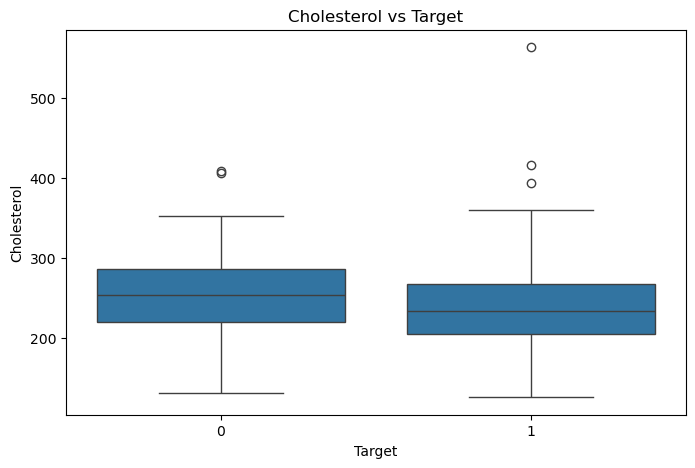

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="chol", data=train_set)

plt.title("Cholesterol vs Target")
plt.xlabel("Target")
plt.ylabel("Cholesterol")

plt.show()

### Cholesterol vs Target Analysis

The boxplot shows substantial overlap between the cholesterol distributions of the two target groups.

The median cholesterol values appear relatively close, and both groups exhibit similar spreads and variability.

Several high-value outliers are present in both categories, indicating that elevated cholesterol levels are not exclusive to a single group within this dataset.

Compared to previously analyzed features such as `oldpeak` and `thalach`, cholesterol appears to provide weaker standalone discriminative power for separating patients based on heart disease status.

These observations suggest that while cholesterol remains medically important, it may contribute more effectively when combined with other clinical features rather than acting as an independent predictor on its own.

###############################################################################################

## Categorical Features vs Target Analysis

In this section, categorical clinical features will be analyzed in relation to the target variable to investigate whether specific categories are associated with heart disease presence.

The objective is to identify potentially informative categorical patterns that may improve machine learning prediction performance.

### Chest Pain Type vs Target

The relationship between chest pain type (`cp`) and heart disease presence will be analyzed to investigate whether specific chest pain categories are associated with different target outcomes.

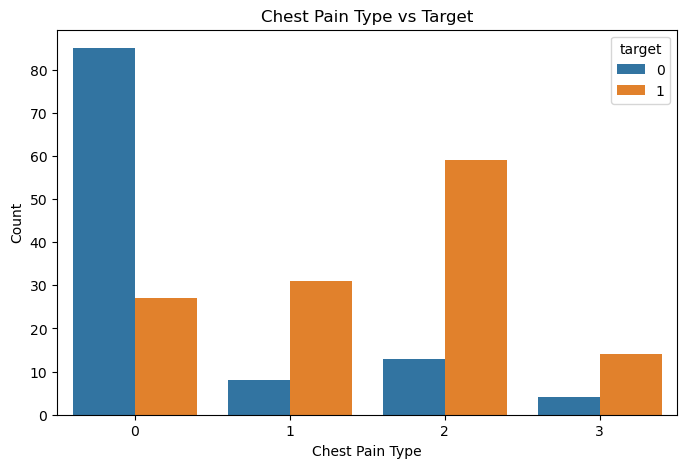

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(x="cp", hue="target", data=train_set)

plt.title("Chest Pain Type vs Target")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

### Chest Pain Type vs Target Analysis

The countplot reveals noticeable differences in target distribution across the various chest pain categories.

Certain chest pain types appear to be strongly associated with one target group more than the other, suggesting that the `cp` feature may contain useful discriminative information for heart disease prediction.

In particular, some categories show a substantial imbalance between the two target classes, indicating that chest pain type may help differentiate between patient conditions more effectively than several previously analyzed numerical features.

These observations are medically meaningful, as different chest pain patterns are often clinically associated with varying cardiovascular risk profiles.

Overall, the `cp` feature appears to be a potentially strong categorical predictor within the dataset.

##################################################

### Exercise Induced Angina vs Target

The relationship between exercise-induced angina (`exang`) and heart disease presence will be analyzed to investigate whether exercise-related chest pain is associated with different target outcomes.

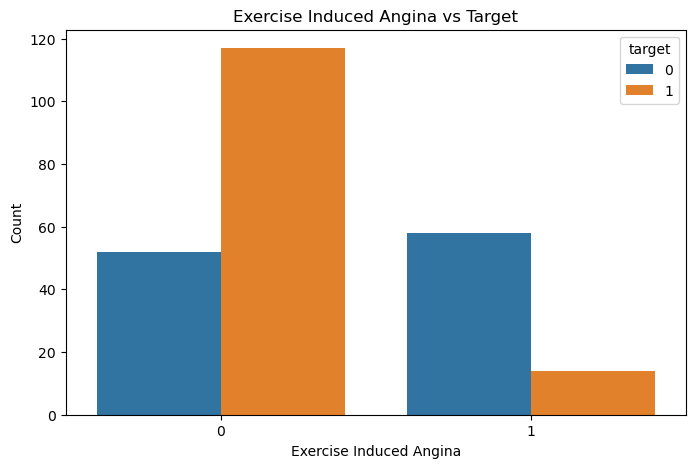

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(x="exang", hue="target", data=train_set)

plt.title("Exercise Induced Angina vs Target")
plt.xlabel("Exercise Induced Angina")
plt.ylabel("Count")

plt.show()

### Exercise Induced Angina vs Target Analysis

The countplot reveals a noticeable association between exercise-induced angina (`exang`) and the target variable.

The distribution of target classes differs substantially between the two `exang` categories, suggesting that this feature may contain useful discriminative information for heart disease prediction.

One category appears to be strongly associated with a higher proportion of one target class, while the opposite pattern is observed in the other category.

Compared to several previously analyzed features, the separation between groups appears relatively clear, indicating that `exang` may serve as a moderately strong categorical predictor.

These observations suggest that exercise-induced angina patterns may provide clinically relevant information when combined with other cardiovascular features in the machine learning model.

##################################################

### Thal vs Target

The relationship between the `thal` feature and heart disease presence will be analyzed to investigate whether specific thal categories are associated with different target outcomes.

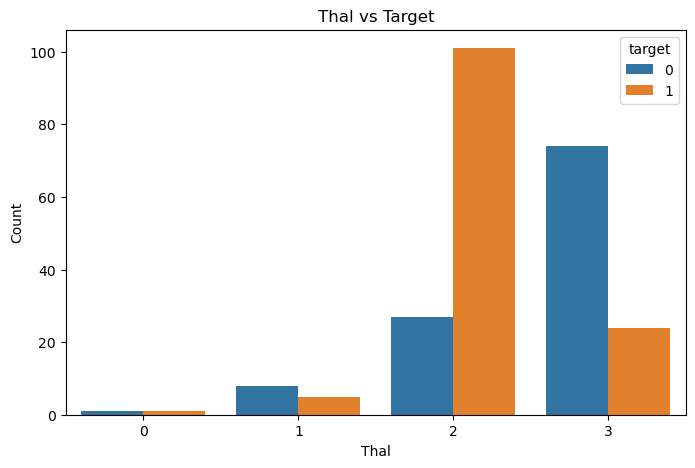

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(x="thal", hue="target", data=train_set)

plt.title("Thal vs Target")
plt.xlabel("Thal")
plt.ylabel("Count")

plt.show()

### Thal vs Target Analysis

The countplot reveals a strong association between `thal` categories and the target variable.

Certain thal categories appear to be heavily associated with one target group more than the other, indicating that this feature may provide substantial discriminative information for heart disease prediction.

In particular, some categories exhibit a clear imbalance between target classes, resulting in noticeably stronger separation compared to many previously analyzed features.

A few categories contain relatively small numbers of observations, which may limit their statistical stability; however, the dominant categories still display meaningful target-related patterns.

Overall, the `thal` feature appears to be one of the strongest categorical predictors observed so far within the dataset.

##################################################

### Slope vs Target

The relationship between the `slope` feature and heart disease presence will be analyzed to investigate whether specific ST segment slope categories are associated with different target outcomes.

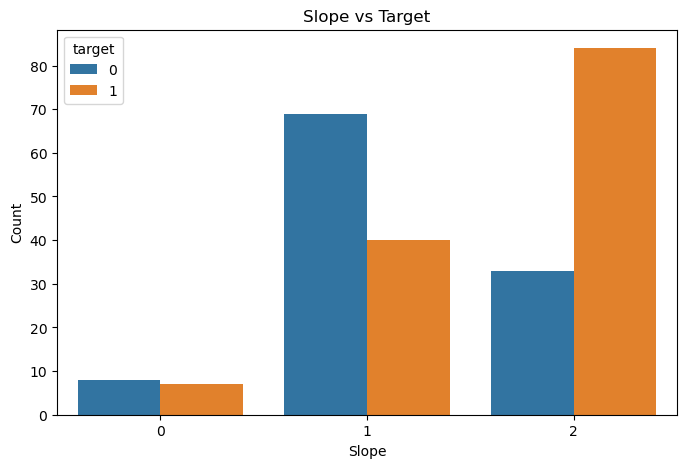

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(x='slope',hue='target',data=train_set)

plt.title("Slope vs Target")
plt.xlabel("Slope")
plt.ylabel("Count")

plt.show()

### Slope vs Target Analysis

The countplot demonstrates noticeable differences in target distribution across the various `slope` categories.

Certain slope categories appear to be more strongly associated with one target class than the other, suggesting that the feature contains meaningful discriminative information for heart disease prediction.

In particular, some categories display a substantial imbalance between target groups, resulting in clearer separation compared to several previously analyzed numerical features.

One category contains relatively few observations, which may reduce its statistical reliability; however, the dominant categories still exhibit informative target-related patterns.

Overall, the `slope` feature appears to be a moderately strong categorical predictor within the dataset.

##################################################

### Sex vs Target

The relationship between patient sex (`sex`) and heart disease presence will be analyzed to investigate whether target distributions differ between male and female patients.

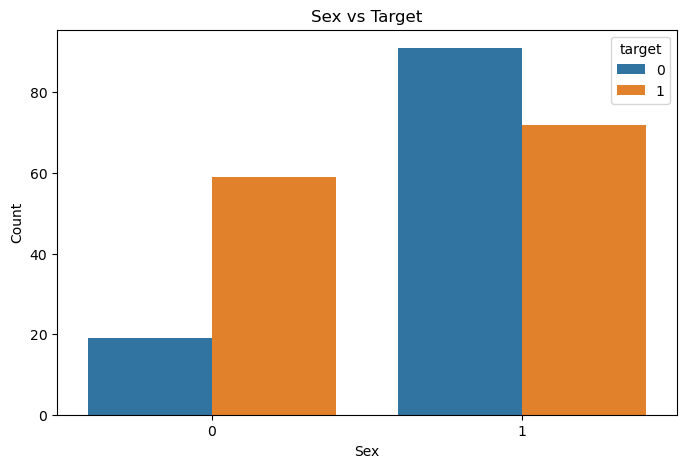

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(x="sex", hue="target", data=train_set)

plt.title("Sex vs Target")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

### Sex vs Target Analysis

The countplot shows a noticeable imbalance between male and female patients within the dataset, with male patients representing a substantially larger portion of the observations.

Differences in target distribution are also visible between the two sex categories, suggesting that the `sex` feature may contain some predictive information related to heart disease presence.

However, compared to several previously analyzed categorical features such as `thal` and `cp`, the separation between target groups appears less pronounced.

The dataset imbalance toward male patients may also introduce potential bias during model training, making it important to consider fairness and generalization performance during later evaluation stages.

Overall, the `sex` feature appears moderately informative but likely weaker than some of the stronger categorical predictors observed earlier.

###############################################################################################

## Correlation Analysis

In this section, correlations between numerical features and the target variable will be analyzed to investigate linear relationships, identify potentially informative variables, and detect possible multicollinearity patterns within the dataset.

### Correlation Heatmap

A correlation heatmap will be used to visualize the strength and direction of relationships between numerical variables and the target feature.

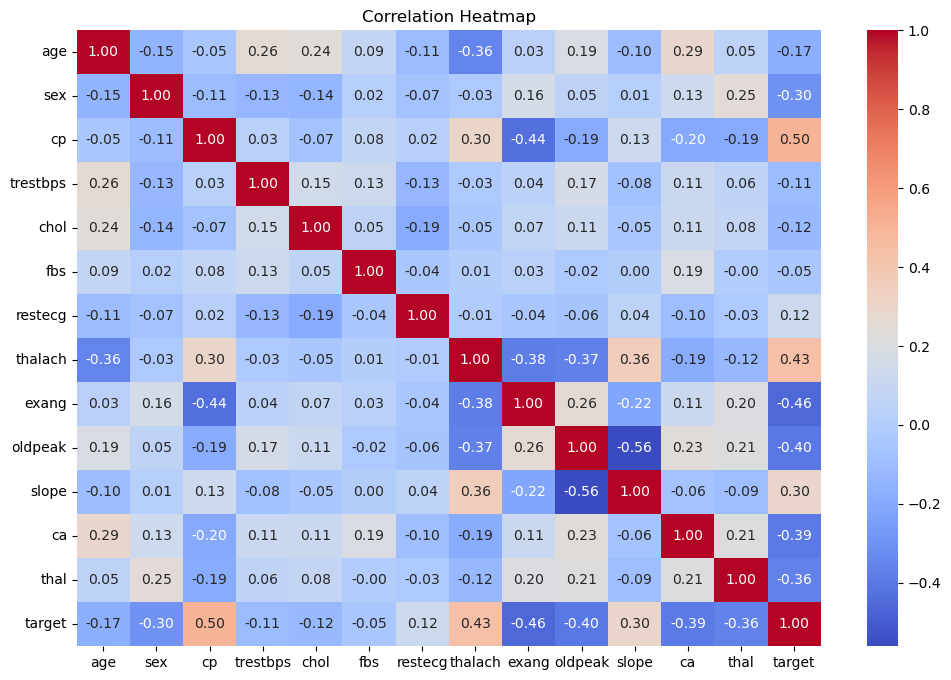

In [45]:
plt.figure(figsize=(12,8))

correlation_matrix = train_set.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Correlation Heatmap Analysis

The correlation heatmap reveals several meaningful relationships between clinical features and the target variable.

Among the strongest correlations with the target are:

- `cp` (chest pain type)
- `exang` (exercise-induced angina)
- `thalach` (maximum heart rate)
- `oldpeak`
- `ca`
- `thal`

These observations are generally consistent with the earlier visual analyses, where these features demonstrated clearer separation between target groups.

On the other hand, features such as `chol`, `fbs`, and `trestbps` exhibit relatively weak linear correlations with the target variable, suggesting limited standalone predictive power in a linear context.

The heatmap also reveals several notable relationships between features themselves. For example, `oldpeak` and `slope` display a moderately strong negative correlation, indicating potential overlap in the clinical information they represent.

Additionally, age appears negatively correlated with maximum heart rate (`thalach`), which is medically plausible since maximum achievable heart rate often decreases with age.

Overall, the correlation analysis supports many of the patterns identified during the earlier exploratory data analysis stages and highlights several potentially important predictors for machine learning modeling.

###############################################################################################

## Prepare the Data for Machine Learning

In this stage, the dataset will be prepared for machine learning by separating features from the target variable, defining numerical and categorical feature groups, applying appropriate preprocessing techniques, and building reusable preprocessing pipelines.

The preprocessing steps will be fitted only on the training data to prevent data leakage and ensure reliable model evaluation.

### Separating Features and Target Variable

The dataset will first be separated into input features (`X`) and the target variable (`y`) to prepare the data for preprocessing and machine learning modeling.

In [46]:
X_train = train_set.drop("target", axis=1)
y_train = train_set["target"]

X_test = test_set.drop("target", axis=1)
y_test = test_set["target"]

### Defining Numerical and Categorical Features

The features will be divided into numerical and categorical groups so that each type can receive the appropriate preprocessing technique.

Numerical features will be scaled, while categorical features may require encoding depending on their meaning and representation.

In [47]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

##################################################

### Scaling Numerical Features

Numerical features will be scaled using `RobustScaler`.

This scaler was selected because several numerical variables contain skewed distributions and medically plausible outliers identified during the exploratory data analysis stage.

Unlike standard scaling methods that rely heavily on the mean and standard deviation, `RobustScaler` uses the median and interquartile range (IQR), making it more resistant to extreme values while preserving important clinical information.

In [48]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

##################################################

### Encoding Categorical Features

Categorical features are currently represented using numerical codes. However, these codes often represent categories rather than true numerical order.

To avoid misleading the model into assuming an artificial ranking between categories, One-Hot Encoding will be applied to categorical features.

In [49]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

The `handle_unknown="ignore"` parameter is used to prevent errors when unseen categories appear during testing or deployment.

If the model encounters a category that was not present during training, the encoder will safely ignore it instead of causing the preprocessing pipeline to fail.

This improves the robustness and reliability of the machine learning workflow, especially in real-world applications where new categorical values may appear over time.

##################################################

### Building the Preprocessing Pipeline

A preprocessing pipeline will be created to automate and standardize the preprocessing workflow for both numerical and categorical features.

The pipeline helps ensure that:
- preprocessing steps are applied consistently
- data leakage is avoided
- training and testing data are handled identically
- deployment becomes easier and more reliable

Numerical features will be scaled using `RobustScaler`, while categorical features will be encoded using `OneHotEncoder`.

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

##################################################

### Applying the Preprocessing Pipeline

The preprocessing pipeline will now be fitted on the training data and then applied to both the training and testing datasets.

Fitting the preprocessing steps only on the training data helps prevent data leakage and ensures that the test set remains completely unseen during model preparation.

In [52]:
X_train_prepared = preprocessor.fit_transform(X_train)

X_test_prepared = preprocessor.transform(X_test)

The preprocessing pipeline is fitted only on the training dataset to ensure that statistical information from the test set does not leak into the training process.

During the fitting stage, the preprocessing components learn:
- scaling statistics for numerical features
- category mappings for categorical features

After learning from the training data, the same transformations are consistently applied to both training and testing datasets.

This approach helps maintain a fair and realistic machine learning evaluation workflow while preventing data leakage.

##################################################

### Inspecting the Prepared Data

After preprocessing, the transformed datasets will be inspected to verify that scaling and encoding were applied successfully and that the data is ready for machine learning modeling.

In [53]:
X_train_prepared.shape

(241, 30)

In [54]:
X_test_prepared.shape

(61, 30)

In [55]:
encoded_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

all_feature_names = numerical_features + list(encoded_feature_names)

all_feature_names

['age',
 'trestbps',
 'chol',
 'thalach',
 'oldpeak',
 'sex_0',
 'sex_1',
 'cp_0',
 'cp_1',
 'cp_2',
 'cp_3',
 'fbs_0',
 'fbs_1',
 'restecg_0',
 'restecg_1',
 'restecg_2',
 'exang_0',
 'exang_1',
 'slope_0',
 'slope_1',
 'slope_2',
 'ca_0',
 'ca_1',
 'ca_2',
 'ca_3',
 'ca_4',
 'thal_0',
 'thal_1',
 'thal_2',
 'thal_3']

###############################################################################################

# Select and Train a Machine Learning Model

In this stage, machine learning models will be trained and evaluated using the prepared dataset.

The objective is to establish an initial baseline model, assess predictive performance using multiple evaluation metrics, and identify areas for future improvement and optimization.

### Building the Logistic Regression Pipeline

A full machine learning pipeline will be created by combining the preprocessing workflow with the Logistic Regression model.

This approach ensures that preprocessing and model training are executed consistently within a single reusable workflow.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

### Training the Logistic Regression Model

The Logistic Regression pipeline will now be trained using the training dataset.

In [57]:
import joblib
from pathlib import Path

model_path = BASE_DIR / "models" / "logistic_regression_pipeline.pkl"

if model_path.exists():
    print("Loading existing trained model...")
    
    log_reg_pipeline = joblib.load(model_path)

else:
    print("Training new model...")
    
    log_reg_pipeline.fit(X_train, y_train)

    joblib.dump(log_reg_pipeline, model_path)

    print("Model trained and saved successfully.")

Loading existing trained model...


### Making Predictions

After training or loading the Logistic Regression pipeline, predictions will be generated on both the training and testing datasets.

Training predictions help check how well the model learned from the training data, while testing predictions are used to evaluate performance on unseen data.

In [58]:
y_train_pred = log_reg_pipeline.predict(X_train)
y_test_pred = log_reg_pipeline.predict(X_test)

### Predicting Risk Probabilities

In addition to class predictions, predicted probabilities will be generated to estimate the likelihood of heart disease risk.

These probabilities will later be used to build a more interpretable risk-based output instead of only returning a binary prediction.

In [59]:
y_train_proba = log_reg_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [60]:
print(y_test_pred[:10])

[0 1 0 1 1 0 1 0 1 0]


In [61]:
print(y_test_proba[:10])

[0.21404791 0.53798535 0.00384345 0.63711787 0.94867517 0.01231449
 0.84237538 0.08713713 0.9835303  0.24151738]


In [62]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Probability": y_test_proba
})

results_df.head(10)

,Actual,Predicted,Probability
0,0,0,0.214048
1,0,1,0.537985
2,0,0,0.003843
3,0,1,0.637118
4,0,1,0.948675
5,0,0,0.012314
6,1,1,0.842375
7,0,0,0.087137
8,1,1,0.983530
9,0,0,0.241517


##################################################

### Model Evaluation Metrics

The Logistic Regression model will be evaluated using multiple classification metrics to assess predictive performance on both training and testing datasets.

The evaluation will include:
- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a more complete understanding of model behavior than accuracy alone, especially in medical classification problems where false negatives may carry significant clinical risk.

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [64]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train Precision:", precision_score(y_train, y_train_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Train F1 Score:", f1_score(y_train, y_train_pred))

Train Accuracy: 0.8838174273858921
Train Precision: 0.8652482269503546
Train Recall: 0.9312977099236641
Train F1 Score: 0.8970588235294118


In [65]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

Test Accuracy: 0.8360655737704918
Test Precision: 0.8484848484848485
Test Recall: 0.8484848484848485
Test F1 Score: 0.8484848484848485


In [66]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



### Logistic Regression Performance Analysis

The Logistic Regression baseline model achieved strong and relatively balanced performance on both the training and testing datasets.

### Training Performance
- Accuracy: approximately 88%
- Precision: approximately 86%
- Recall: approximately 93%
- F1-score: approximately 90%

### Testing Performance
- Accuracy: approximately 84%
- Precision: approximately 85%
- Recall: approximately 85%
- F1-score: approximately 85%

The relatively small performance gap between training and testing results suggests that the model generalizes reasonably well and does not exhibit severe overfitting.

The recall score is particularly important in this medical classification problem because it reflects the model’s ability to correctly identify patients with heart disease while minimizing false negative predictions.

Overall, the Logistic Regression model provides a strong and interpretable baseline for future comparison with more advanced machine learning models.

##################################################

### Confusion Matrix

A confusion matrix will be used to visualize the model predictions compared to the actual target values.

This helps identify:
- correctly classified cases
- false positives
- false negatives

which is especially important in medical classification problems where prediction errors may carry clinical significance.

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

cm

array([[23,  5],
       [ 5, 28]])

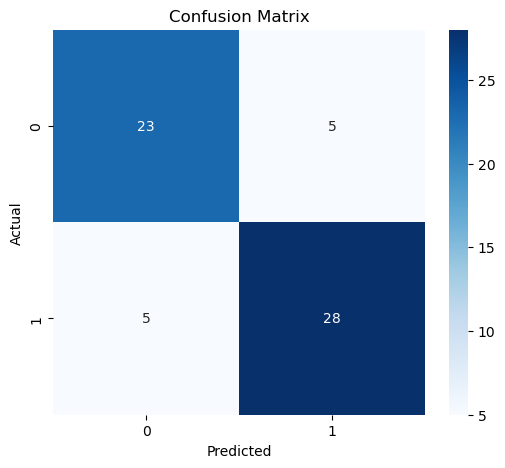

In [68]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that the Logistic Regression model achieved relatively balanced classification performance across both target classes.

### Correct Predictions
- 23 healthy patients were correctly classified as negative cases (True Negatives).
- 28 patients with heart disease were correctly identified (True Positives).

### Prediction Errors
- 5 healthy patients were incorrectly classified as having heart disease (False Positives).
- 5 patients with heart disease were incorrectly classified as healthy (False Negatives).

The relatively small number of false negatives is especially important in this medical classification problem because failing to identify a patient with heart disease may carry greater clinical risk than producing additional false alarms.

The confusion matrix also suggests that the model maintains a balanced tradeoff between sensitivity and specificity without showing strong bias toward either target class.

Overall, the Logistic Regression baseline model demonstrates stable and reliable classification behavior on the testing dataset.

##################################################

### Generalization Analysis

The Logistic Regression model demonstrates relatively consistent performance between the training and testing datasets.

The performance gap between train and test metrics remains relatively small, suggesting that the model generalizes reasonably well to unseen data and does not exhibit severe overfitting.

At the same time, the model maintains solid predictive performance on both datasets, indicating that it is not significantly underfitting the problem either.

These observations suggest that the current preprocessing pipeline and baseline modeling approach provide a stable foundation for future experimentation with more advanced machine learning algorithms.

##################################################
##################################################

## Decision Tree Classifier

A Decision Tree classifier will be trained and evaluated to compare its performance against the Logistic Regression baseline model.

Unlike Logistic Regression, Decision Trees can capture nonlinear relationships and hierarchical decision patterns within the dataset, making them useful for exploring more complex feature interactions.

In [69]:
from sklearn.tree import DecisionTreeClassifier

In [70]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

### Training and Saving the Decision Tree Model

The Decision Tree pipeline will be trained and saved for reuse.

If a previously trained model already exists, it will be loaded directly to avoid unnecessary retraining.

In [71]:
decision_tree_path = BASE_DIR / "models" / "decision_tree_pipeline.pkl"

if decision_tree_path.exists():
    print("Loading existing Decision Tree model...")
    
    decision_tree_pipeline = joblib.load(decision_tree_path)

else:
    print("Training new Decision Tree model...")
    
    decision_tree_pipeline.fit(X_train, y_train)

    joblib.dump(decision_tree_pipeline, decision_tree_path)

    print("Decision Tree model trained and saved successfully.")

Loading existing Decision Tree model...


### Decision Tree Model Evaluation

The Decision Tree model will be evaluated using the same metrics used for the Logistic Regression baseline model.

Using the same evaluation metrics ensures a fair comparison between models.

In [72]:
y_train_pred_dt = decision_tree_pipeline.predict(X_train)
y_test_pred_dt = decision_tree_pipeline.predict(X_test)

In [73]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Train Precision:", precision_score(y_train, y_train_pred_dt))
print("Train Recall:", recall_score(y_train, y_train_pred_dt))
print("Train F1 Score:", f1_score(y_train, y_train_pred_dt))

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("Test Precision:", precision_score(y_test, y_test_pred_dt))
print("Test Recall:", recall_score(y_test, y_test_pred_dt))
print("Test F1 Score:", f1_score(y_test, y_test_pred_dt))

Train Accuracy: 0.9336099585062241
Train Precision: 0.9136690647482014
Train Recall: 0.9694656488549618
Train F1 Score: 0.9407407407407408

Test Accuracy: 0.7868852459016393
Test Precision: 0.8125
Test Recall: 0.7878787878787878
Test F1 Score: 0.8


In [74]:
print(classification_report(y_test, y_test_pred_dt))

              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



### Decision Tree Performance Analysis

The Decision Tree classifier achieved strong performance on the training dataset but demonstrated weaker generalization performance on the testing dataset compared to the Logistic Regression baseline model.

### Training Performance
- Accuracy: approximately 93%
- Recall: approximately 97%
- F1-score: approximately 94%

### Testing Performance
- Accuracy: approximately 79%
- Recall: approximately 79%
- F1-score: approximately 80%

The noticeable performance gap between training and testing results suggests that the Decision Tree model exhibits moderate overfitting.

Although the model learned the training patterns very effectively, its ability to generalize to unseen data was weaker than expected.

This behavior is common with Decision Trees because they are highly flexible models that can easily memorize training data patterns, especially when dataset size is limited.

Compared to the Logistic Regression baseline model, the Decision Tree achieved higher training performance but lower testing performance, indicating that the simpler linear model generalized more effectively for this dataset.

##################################################
##################################################

## Random Forest Classifier

A Random Forest classifier will be trained and evaluated as an ensemble-based machine learning model.

Unlike a single Decision Tree, Random Forest combines predictions from multiple trees to improve generalization performance and reduce overfitting.

This approach often provides stronger predictive performance and better stability on unseen data.

In [75]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ))
])

### Training and Saving the Random Forest Model

The Random Forest pipeline will be trained and saved for reuse.

If a previously trained model already exists, it will be loaded directly to avoid unnecessary retraining.

In [77]:
random_forest_path = BASE_DIR / "models" / "random_forest_pipeline.pkl"

if random_forest_path.exists():
    print("Loading existing Random Forest model...")
    
    random_forest_pipeline = joblib.load(random_forest_path)

else:
    print("Training new Random Forest model...")
    
    random_forest_pipeline.fit(X_train, y_train)

    joblib.dump(random_forest_pipeline, random_forest_path)

    print("Random Forest model trained and saved successfully.")

Loading existing Random Forest model...


### Random Forest Model Evaluation

The Random Forest classifier will be evaluated using the same classification metrics used for the previous models to enable fair performance comparison.

In [78]:
y_train_pred_rf = random_forest_pipeline.predict(X_train)
y_test_pred_rf = random_forest_pipeline.predict(X_test)

In [79]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Train Precision:", precision_score(y_train, y_train_pred_rf))
print("Train Recall:", recall_score(y_train, y_train_pred_rf))
print("Train F1 Score:", f1_score(y_train, y_train_pred_rf))

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Test Precision:", precision_score(y_test, y_test_pred_rf))
print("Test Recall:", recall_score(y_test, y_test_pred_rf))
print("Test F1 Score:", f1_score(y_test, y_test_pred_rf))

Train Accuracy: 0.9294605809128631
Train Precision: 0.9014084507042254
Train Recall: 0.9770992366412213
Train F1 Score: 0.9377289377289377

Test Accuracy: 0.7868852459016393
Test Precision: 0.7941176470588235
Test Recall: 0.8181818181818182
Test F1 Score: 0.8059701492537313


In [80]:
print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.75      0.76        28
           1       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



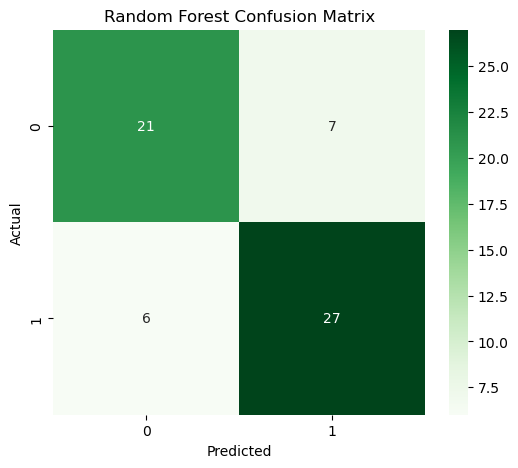

In [81]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### Random Forest Performance Analysis

The Random Forest classifier achieved very strong performance on the training dataset but demonstrated weaker generalization performance on the testing dataset.

### Training Performance
- Accuracy: approximately 93%
- Recall: approximately 98%
- F1-score: approximately 94%

### Testing Performance
- Accuracy: approximately 79%
- Recall: approximately 82%
- F1-score: approximately 81%

Although Random Forest is designed to reduce overfitting compared to a single Decision Tree, the model still exhibited a noticeable performance gap between training and testing results.

This behavior may be influenced by:
- the relatively small dataset size
- untuned hyperparameters
- the possibility that the dataset relationships are closer to linear patterns

Compared to the Logistic Regression baseline model, the Random Forest classifier achieved higher training performance but lower testing performance, indicating weaker generalization on unseen data.

These results highlight an important machine learning principle: more complex models do not always outperform simpler models, especially when dataset size is limited.

##################################################
##################################################

## Model Comparison

The trained machine learning models will now be compared using the same evaluation metrics to identify the strongest baseline performer and analyze generalization behavior across different algorithms.

In [82]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Train Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_train, y_train_pred_dt),
        accuracy_score(y_train, y_train_pred_rf)
    ],

    "Test Accuracy": [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_dt),
        accuracy_score(y_test, y_test_pred_rf)
    ],

    "Test Precision": [
        precision_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred_dt),
        precision_score(y_test, y_test_pred_rf)
    ],

    "Test Recall": [
        recall_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred_dt),
        recall_score(y_test, y_test_pred_rf)
    ],

    "Test F1": [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_dt),
        f1_score(y_test, y_test_pred_rf)
    ]
})

comparison_df

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.883817,0.836066,0.848485,0.848485,0.848485
1,Decision Tree,0.933610,0.786885,0.812500,0.787879,0.800000
2,Random Forest,0.929461,0.786885,0.794118,0.818182,0.805970


##################################################
##################################################

## Support Vector Machine Classifier

A Support Vector Machine classifier will be trained and evaluated as an additional baseline model.

SVM is useful for classification tasks, especially on smaller datasets, and can capture more complex decision boundaries compared to simple linear models.

In [83]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

In [84]:
svm_path = BASE_DIR / "models" / "svm_pipeline.pkl"

if svm_path.exists():
    print("Loading existing SVM model...")
    svm_pipeline = joblib.load(svm_path)

else:
    print("Training new SVM model...")
    svm_pipeline.fit(X_train, y_train)

    joblib.dump(svm_pipeline, svm_path)
    print("SVM model trained and saved successfully.")

Loading existing SVM model...


In [85]:
y_train_pred_svm = svm_pipeline.predict(X_train)
y_test_pred_svm = svm_pipeline.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_svm))
print("Train Precision:", precision_score(y_train, y_train_pred_svm))
print("Train Recall:", recall_score(y_train, y_train_pred_svm))
print("Train F1 Score:", f1_score(y_train, y_train_pred_svm))

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("Test Precision:", precision_score(y_test, y_test_pred_svm))
print("Test Recall:", recall_score(y_test, y_test_pred_svm))
print("Test F1 Score:", f1_score(y_test, y_test_pred_svm))

Train Accuracy: 0.9253112033195021
Train Precision: 0.900709219858156
Train Recall: 0.9694656488549618
Train F1 Score: 0.9338235294117647

Test Accuracy: 0.7868852459016393
Test Precision: 0.8125
Test Recall: 0.7878787878787878
Test F1 Score: 0.8


In [86]:
print(classification_report(y_test, y_test_pred_svm))

              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



### SVM Performance Analysis

The Support Vector Machine classifier achieved strong training performance but weaker testing generalization compared to the Logistic Regression baseline model.

### Training Performance
- Accuracy: approximately 93%
- Recall: approximately 97%
- F1-score: approximately 93%

### Testing Performance
- Accuracy: approximately 79%
- Recall: approximately 79%
- F1-score: approximately 80%

The noticeable difference between training and testing performance suggests that the SVM model also exhibits moderate overfitting on this dataset.

Despite the ability of SVM models to capture more complex decision boundaries, the Logistic Regression baseline continued to outperform the SVM classifier on unseen data.

These findings suggest that:
- the dataset may contain relatively simple or near-linear relationships
- the dataset size may limit the advantages of more complex models
- additional hyperparameter tuning may be required for SVM optimization

Overall, Logistic Regression remains the strongest baseline model so far in terms of generalization performance.

##################################################
##################################################

## Gradient Boosting Classifier

A Gradient Boosting classifier will be trained and evaluated as an additional ensemble-based machine learning model.

Unlike Random Forest, Gradient Boosting builds trees sequentially, where each new tree attempts to correct the errors made by the previous trees.

This often allows the model to capture more complex patterns and improve predictive performance.

In [87]:
from sklearn.ensemble import GradientBoostingClassifier

In [88]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [89]:
gradient_boosting_path = BASE_DIR / "models" / "gradient_boosting_pipeline.pkl"

if gradient_boosting_path.exists():
    print("Loading existing Gradient Boosting model...")
    
    gradient_boosting_pipeline = joblib.load(gradient_boosting_path)

else:
    print("Training new Gradient Boosting model...")
    
    gradient_boosting_pipeline.fit(X_train, y_train)

    joblib.dump(gradient_boosting_pipeline, gradient_boosting_path)

    print("Gradient Boosting model trained and saved successfully.")

Loading existing Gradient Boosting model...


In [90]:
y_train_pred_gb = gradient_boosting_pipeline.predict(X_train)
y_test_pred_gb = gradient_boosting_pipeline.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_gb))
print("Train Precision:", precision_score(y_train, y_train_pred_gb))
print("Train Recall:", recall_score(y_train, y_train_pred_gb))
print("Train F1 Score:", f1_score(y_train, y_train_pred_gb))

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred_gb))
print("Test Precision:", precision_score(y_test, y_test_pred_gb))
print("Test Recall:", recall_score(y_test, y_test_pred_gb))
print("Test F1 Score:", f1_score(y_test, y_test_pred_gb))

Train Accuracy: 0.995850622406639
Train Precision: 0.9924242424242424
Train Recall: 1.0
Train F1 Score: 0.9961977186311787

Test Accuracy: 0.7704918032786885
Test Precision: 0.7878787878787878
Test Recall: 0.7878787878787878
Test F1 Score: 0.7878787878787878


In [91]:
print(classification_report(y_test, y_test_pred_gb))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



### Gradient Boosting Performance Analysis

The Gradient Boosting classifier achieved extremely high training performance but demonstrated the weakest testing generalization among the evaluated baseline models.

### Training Performance
- Accuracy: approximately 99.6%
- Recall: 100%
- F1-score: approximately 99.6%

### Testing Performance
- Accuracy: approximately 77%
- Recall: approximately 79%
- F1-score: approximately 79%

The very large gap between training and testing performance indicates severe overfitting.

The model effectively memorized the training dataset but failed to generalize effectively to unseen data.

This behavior is likely influenced by:
- the relatively small dataset size
- the high flexibility of boosting models
- untuned hyperparameters

Compared to all previously evaluated models, Logistic Regression continued to demonstrate the strongest generalization performance on the testing dataset.

These findings reinforce the importance of balancing model complexity with dataset size and highlight that more complex ensemble methods do not always outperform simpler models.

In [92]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## XGBoost Classifier

An XGBoost classifier will be trained and evaluated as an advanced gradient boosting model optimized for structured tabular datasets.

XGBoost extends traditional boosting methods with additional regularization and optimization techniques that often improve generalization performance and reduce overfitting.

In [93]:
from xgboost import XGBClassifier

In [94]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [95]:
xgb_path = BASE_DIR / "models" / "xgboost_pipeline.pkl"

if xgb_path.exists():
    print("Loading existing XGBoost model...")
    
    xgb_pipeline = joblib.load(xgb_path)

else:
    print("Training new XGBoost model...")
    
    xgb_pipeline.fit(X_train, y_train)

    joblib.dump(xgb_pipeline, xgb_path)

    print("XGBoost model trained and saved successfully.")

Loading existing XGBoost model...


In [96]:
y_train_pred_xgb = xgb_pipeline.predict(X_train)
y_test_pred_xgb = xgb_pipeline.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("Train Precision:", precision_score(y_train, y_train_pred_xgb))
print("Train Recall:", recall_score(y_train, y_train_pred_xgb))
print("Train F1 Score:", f1_score(y_train, y_train_pred_xgb))

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred_xgb))
print("Test Precision:", precision_score(y_test, y_test_pred_xgb))
print("Test Recall:", recall_score(y_test, y_test_pred_xgb))
print("Test F1 Score:", f1_score(y_test, y_test_pred_xgb))

Train Accuracy: 0.9875518672199171
Train Precision: 0.9776119402985075
Train Recall: 1.0
Train F1 Score: 0.9886792452830189

Test Accuracy: 0.7704918032786885
Test Precision: 0.8275862068965517
Test Recall: 0.7272727272727273
Test F1 Score: 0.7741935483870968


In [97]:
print(classification_report(y_test, y_test_pred_xgb))

              precision    recall  f1-score   support

           0       0.72      0.82      0.77        28
           1       0.83      0.73      0.77        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.78      0.77      0.77        61



### XGBoost Performance Analysis

The XGBoost classifier achieved extremely high training performance but demonstrated weak generalization performance on the testing dataset.

### Training Performance
- Accuracy: approximately 99%
- Recall: 100%
- F1-score: approximately 99%

### Testing Performance
- Accuracy: approximately 77%
- Recall: approximately 73%
- F1-score: approximately 77%

The large gap between training and testing results indicates strong overfitting.

Although XGBoost is a highly powerful boosting algorithm, the model appeared to memorize the training dataset rather than generalizing effectively to unseen data.

The relatively lower recall score on the testing dataset is especially important in this medical classification problem because it indicates that a larger proportion of patients with heart disease were missed by the model.

These findings suggest that:
- the dataset size may be too limited for highly complex boosting models
- the underlying feature relationships may be closer to linear patterns
- additional hyperparameter tuning and stronger regularization would likely be required to improve generalization performance

Despite the advanced capabilities of XGBoost, Logistic Regression remained the strongest baseline model in terms of stability and generalization performance on unseen data.

###############################################################################################

# Fine-Tuning the Machine Learning Models

In this stage, the strongest baseline models will be optimized using cross-validation and hyperparameter tuning techniques.

The objective is to improve generalization performance, reduce overfitting, and identify the best model configuration for heart disease prediction.

## Hyperparameter Tuning for Logistic Regression

Logistic Regression will be optimized first because it demonstrated the strongest overall generalization performance during baseline model comparison.

### Logistic Regression Grid Search

GridSearchCV will be used to test different Logistic Regression hyperparameter combinations using cross-validation.

This helps identify the best configuration based on validation performance instead of relying only on a single train-test split.

In [98]:
from sklearn.model_selection import GridSearchCV

log_reg_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

grid_search_log_reg = GridSearchCV(
    estimator=log_reg_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search_log_reg.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [99]:
print("Best Parameters:", grid_search_log_reg.best_params_)
print("Best CV Recall:", grid_search_log_reg.best_score_)

Best Parameters: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Recall: 0.9162393162393162


##################################################
##################################################

## Hyperparameter Tuning for Random Forest

Random Forest hyperparameters will be optimized using GridSearchCV and cross-validation to reduce overfitting and improve generalization performance.

In [100]:
rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [101]:
rf_param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5, 7],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [102]:
rf_grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [103]:
rf_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [50, 100]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [104]:
print("Best Parameters:", rf_grid_search.best_params_)
print("Best CV Recall:", rf_grid_search.best_score_)

Best Parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV Recall: 0.9236467236467236


###############################################################################################

# Final Evaluation on the Test Set

After completing hyperparameter tuning using cross-validation, the optimized models will now be evaluated on the unseen testing dataset.

This final evaluation step measures real-world generalization performance and helps identify the most reliable model for heart disease prediction.

## Evaluating the Tuned Logistic Regression Model

The optimized Logistic Regression model will be evaluated on the testing dataset using classification metrics and confusion matrix analysis.

In [105]:
best_log_reg_model = grid_search_log_reg.best_estimator_

In [106]:
y_test_pred_tuned_lr = best_log_reg_model.predict(X_test)

In [107]:
print("Tuned Logistic Regression Accuracy:",
      accuracy_score(y_test, y_test_pred_tuned_lr))

print("Tuned Logistic Regression Precision:",
      precision_score(y_test, y_test_pred_tuned_lr))

print("Tuned Logistic Regression Recall:",
      recall_score(y_test, y_test_pred_tuned_lr))

print("Tuned Logistic Regression F1 Score:",
      f1_score(y_test, y_test_pred_tuned_lr))

Tuned Logistic Regression Accuracy: 0.8360655737704918
Tuned Logistic Regression Precision: 0.8285714285714286
Tuned Logistic Regression Recall: 0.8787878787878788
Tuned Logistic Regression F1 Score: 0.8529411764705882


In [108]:
print(classification_report(y_test, y_test_pred_tuned_lr))

              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



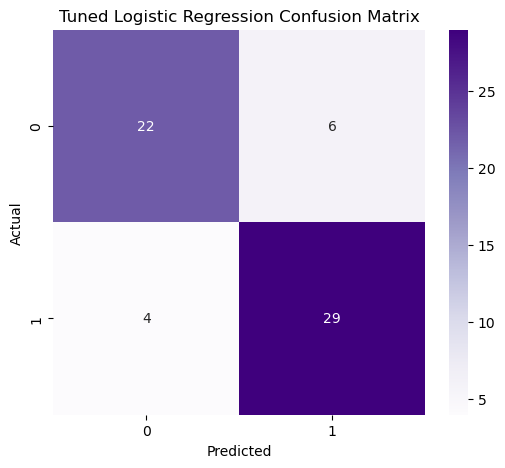

In [109]:
cm_tuned_lr = confusion_matrix(y_test, y_test_pred_tuned_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tuned_lr,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Logistic Regression Confusion Matrix")

plt.show()

### Tuned Logistic Regression Test Performance

The tuned Logistic Regression model maintained strong and stable generalization performance on the unseen testing dataset.

### Final Testing Performance
- Accuracy: approximately 84%
- Precision: approximately 83%
- Recall: approximately 88%
- F1-score: approximately 85%

Compared to the baseline Logistic Regression model, the tuned version achieved improved recall performance while maintaining similar overall accuracy.

This improvement is particularly important in the medical classification setting because higher recall reduces the number of false negative predictions and increases the likelihood of correctly identifying patients with heart disease.

Although precision decreased slightly, the model became more sensitive to positive cases, which is often preferable in healthcare-related prediction tasks.

Overall, the tuned Logistic Regression model demonstrated the strongest balance between:
- generalization performance
- stability
- recall
- clinical usefulness

among all evaluated models.

##################################################
##################################################

## Evaluating the Tuned Random Forest Model

The optimized Random Forest model will now be evaluated on the testing dataset to measure its final generalization performance after hyperparameter tuning.

In [110]:
best_rf_model = rf_grid_search.best_estimator_

In [111]:
y_test_pred_tuned_rf = best_rf_model.predict(X_test)

In [112]:
print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, y_test_pred_tuned_rf))

print("Tuned Random Forest Precision:",
      precision_score(y_test, y_test_pred_tuned_rf))

print("Tuned Random Forest Recall:",
      recall_score(y_test, y_test_pred_tuned_rf))

print("Tuned Random Forest F1 Score:",
      f1_score(y_test, y_test_pred_tuned_rf))

Tuned Random Forest Accuracy: 0.8032786885245902
Tuned Random Forest Precision: 0.8
Tuned Random Forest Recall: 0.8484848484848485
Tuned Random Forest F1 Score: 0.8235294117647058


In [113]:
print(classification_report(y_test, y_test_pred_tuned_rf))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



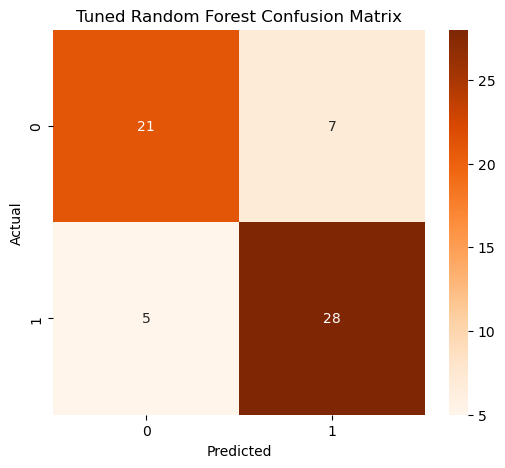

In [114]:
cm_tuned_rf = confusion_matrix(y_test, y_test_pred_tuned_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tuned_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest Confusion Matrix")

plt.show()

### Tuned Random Forest Test Performance

The tuned Random Forest model demonstrated improved performance compared to the baseline Random Forest configuration.

### Final Testing Performance
- Accuracy: approximately 80%
- Precision: approximately 80%
- Recall: approximately 85%
- F1-score: approximately 82%

Hyperparameter tuning successfully improved generalization performance and reduced overfitting behavior by limiting tree complexity.

The shallower tree depth selected during tuning contributed to more stable testing performance.

Despite these improvements, the tuned Random Forest model still underperformed compared to the tuned Logistic Regression model across most evaluation metrics.

These results further support the observation that:
- simpler and more regularized models generalize better on this dataset
- highly flexible ensemble methods may not provide additional benefits for relatively small medical tabular datasets

Overall, Logistic Regression remained the strongest final model candidate for this heart disease prediction system.

##################################################
################################################## 

## ROC Curve and AUC Analysis

Receiver Operating Characteristic (ROC) analysis will be used to evaluate the classification performance of the final tuned Logistic Regression model across different decision thresholds.

The Area Under the Curve (AUC) metric provides a threshold-independent measure of the model’s ability to distinguish between patients with and without heart disease.

In [115]:
from sklearn.metrics import roc_curve, roc_auc_score

In [116]:
y_test_proba_lr = best_log_reg_model.predict_proba(X_test)[:, 1]

In [117]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_lr)

In [118]:
auc_score = roc_auc_score(y_test, y_test_proba_lr)

print("AUC Score:", auc_score)

AUC Score: 0.9123376623376624


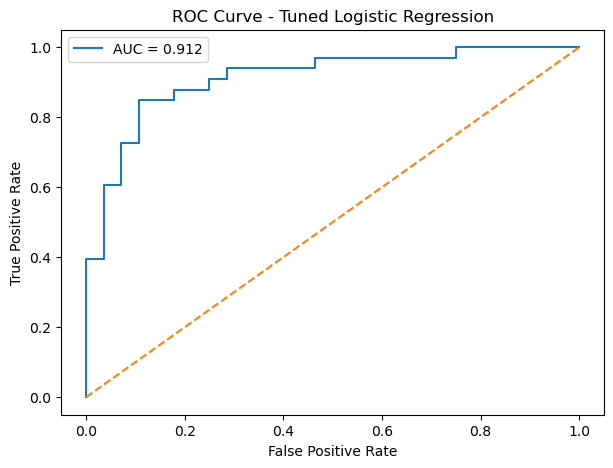

In [119]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")

plt.legend()

plt.show()

## ROC Curve and AUC Analysis

The tuned Logistic Regression model achieved an AUC score of approximately 0.91, indicating excellent classification capability.

The ROC curve remained significantly above the random classification baseline, demonstrating that the model effectively distinguishes between patients with and without heart disease across different decision thresholds.

### Key Observations

- The model maintained a high true positive rate while keeping false positive rates relatively controlled.
- The ROC curve remained close to the upper-left region of the graph, which indicates strong discriminative performance.
- The AUC score above 0.90 suggests excellent overall classification quality.

These results further confirm that the tuned Logistic Regression model provides strong and reliable predictive performance for this heart disease prediction task.

The ROC/AUC analysis also highlights that the model remains effective across multiple classification thresholds rather than depending only on a single fixed probability cutoff.

###############################################################################################

# Saving the Final Model

The final tuned Logistic Regression pipeline will be saved for deployment and future inference.

The saved pipeline includes:
- preprocessing steps
- feature scaling
- categorical encoding
- trained classification model

Saving the complete pipeline ensures consistent preprocessing during future predictions.

In [120]:
final_model_path = BASE_DIR / "models" / "final_logistic_regression_model.pkl"

joblib.dump(best_log_reg_model, final_model_path)

print("Final model saved successfully.")

Final model saved successfully.
